# Text Classification

In [2]:
import pandas as pd

df = pd.read_csv("Data/ham-spam.csv")
df = df.sample(frac=1, random_state=0)
df.head()

,IsSpam,Text
993,1,utf date course utf diminish weight our table...
859,1,utf any drugs eur utf for dose have you ever ...
298,0,expert finderhttps expertfinder enron com
553,1,and courtiers ministerssubsegment founded res...
672,1,for our clients fargo dear customer have updat...


In [3]:
df = df.drop_duplicates()
df.groupby("IsSpam").describe()

Text                                                               
       count unique                                                top freq
IsSpam                                                                     
0        499    499         expert finderhttps expertfinder enron com     1
1        500    500   utf date course utf diminish weight our table...    1

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

X = df["Text"]
y = df["IsSpam"]

max_words = 10000  # Limit the vocabulary to the 10,000 most common words
max_length = 500

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
X = pad_sequences(sequences, maxlen=max_length)

In [8]:
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Embedding(max_words, 32, input_length=max_length))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 500, 32)           320000    
                                                                 
 flatten_2 (Flatten)         (None, 16000)             0         
                                                                 
 dense_4 (Dense)             (None, 128)               2048128   
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2368257 (9.03 MB)
Trainable params: 2368257 (9.03 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
hist = model.fit(X, y, validation_split=0.2, epochs=5, batch_size=20)

Epoch 1/5
40/40 [==============================] - 0s 4ms/step - loss: 0.6601 - accuracy: 0.6070 - val_loss: 0.6233 - val_accuracy: 0.6500
Epoch 2/5
40/40 [==============================] - 0s 3ms/step - loss: 0.3883 - accuracy: 0.8611 - val_loss: 0.2688 - val_accuracy: 0.9400
Epoch 3/5
40/40 [==============================] - 0s 3ms/step - loss: 0.1121 - accuracy: 0.9650 - val_loss: 0.1311 - val_accuracy: 0.9700
Epoch 4/5
40/40 [==============================] - 0s 3ms/step - loss: 0.0533 - accuracy: 0.9837 - val_loss: 0.2160 - val_accuracy: 0.9000
Epoch 5/5
40/40 [==============================] - 0s 3ms/step - loss: 0.0243 - accuracy: 0.9937 - val_loss: 0.1176 - val_accuracy: 0.9700


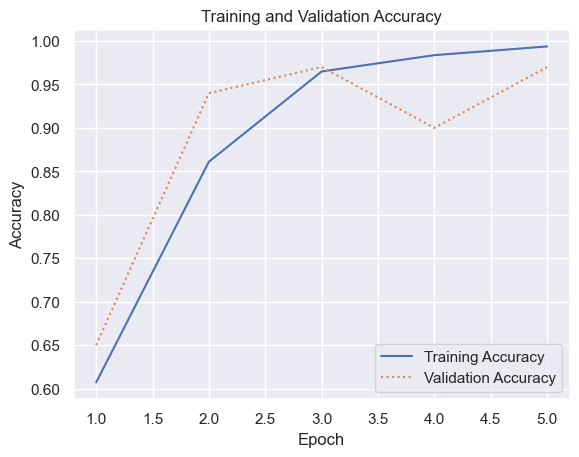

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

In [15]:
def is_spam(text: str) -> int:
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length)
    return model.predict(padded_sequence)[0][0]


is_spam(
    "Can you attend a code review on Tuesday? Need to make sure the logic is rock solid."
)

1/1 [==============================] - 0s 12ms/step


0.34400487

In [16]:
is_spam("Why pay for more expensive meds when you can order them online and save $$$")

1/1 [==============================] - 0s 10ms/step


0.9877728

## Automating Text Vectorization

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    Flatten,
    InputLayer,
    TextVectorization,
)
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(InputLayer(input_shape=(1,), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 32, input_length=max_length))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 500)               0         
 ctorization)                                                    
                                                                 
 embedding_3 (Embedding)     (None, 500, 32)           320000    
                                                                 
 flatten_3 (Flatten)         (None, 16000)             0         
                                                                 
 dense_6 (Dense)             (None, 128)               2048128   
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2368257 (9.03 MB)
Trainable params: 2368257 (9.03 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [19]:
X = df["Text"]
y = df["IsSpam"]

model.layers[0].adapt(X)

In [20]:
hist = model.fit(X, y, validation_split=0.2, epochs=5, batch_size=20)

Epoch 1/5
40/40 [==============================] - 0s 4ms/step - loss: 0.5398 - accuracy: 0.7309 - val_loss: 0.3014 - val_accuracy: 0.9000
Epoch 2/5
40/40 [==============================] - 0s 3ms/step - loss: 0.1555 - accuracy: 0.9675 - val_loss: 0.1059 - val_accuracy: 0.9700
Epoch 3/5
40/40 [==============================] - 0s 3ms/step - loss: 0.0549 - accuracy: 0.9825 - val_loss: 0.0863 - val_accuracy: 0.9650
Epoch 4/5
40/40 [==============================] - 0s 4ms/step - loss: 0.0366 - accuracy: 0.9912 - val_loss: 0.1425 - val_accuracy: 0.9400
Epoch 5/5
40/40 [==============================] - 0s 4ms/step - loss: 0.0266 - accuracy: 0.9950 - val_loss: 0.0717 - val_accuracy: 0.9750


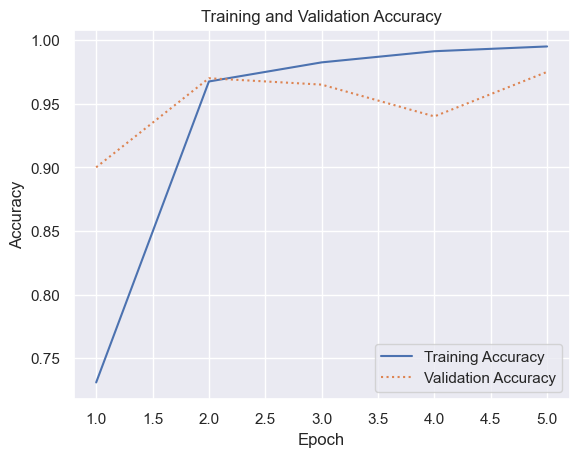

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

In [22]:
text = "Why pay for more expensive meds when you can order them online and save $$$"
model.predict([text])[0][0]

1/1 [==============================] - 0s 45ms/step


0.9150761